In [298]:
import os

#import lib
import model
import pandas as pd

In [299]:
#load the covid19 dataset
df = pd.read_csv(r'C:\Users\vvahe\Downloads\covid19.csv')
df.head()

,date,areaName,newCasesByPublishDate,cumCasesByPublishDate,newDeaths28DaysByPublishDate,cumDeaths28DaysByPublishDate,cumDeaths28DaysByPublishDateRate,newDeaths28DaysByDeathDate,cumDeaths28DaysByDeathDate,cumDeaths28DaysByDeathDateRate
0,2020-03-11,South West,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN
1,2020-03-12,South West,NaN,NaN,NaN,NaN,NaN,0.0,1.0,NaN
2,2020-03-13,South West,NaN,NaN,NaN,NaN,NaN,0.0,1.0,NaN
3,2020-03-14,South West,NaN,NaN,NaN,NaN,NaN,1.0,2.0,NaN
4,2020-03-15,South West,NaN,NaN,NaN,NaN,NaN,1.0,3.0,0.1


In [300]:
#showing columns and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3481 entries, 0 to 3480
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   date                              3481 non-null   str    
 1   areaName                          3481 non-null   str    
 2   newCasesByPublishDate             3284 non-null   float64
 3   cumCasesByPublishDate             3289 non-null   float64
 4   newDeaths28DaysByPublishDate      2657 non-null   float64
 5   cumDeaths28DaysByPublishDate      2674 non-null   float64
 6   cumDeaths28DaysByPublishDateRate  2674 non-null   float64
 7   newDeaths28DaysByDeathDate        3475 non-null   float64
 8   cumDeaths28DaysByDeathDate        3475 non-null   float64
 9   cumDeaths28DaysByDeathDateRate    3451 non-null   float64
dtypes: float64(8), str(2)
memory usage: 272.1 KB


In [301]:
df.describe(include = 'all')

,date,areaName,newCasesByPublishDate,cumCasesByPublishDate,newDeaths28DaysByPublishDate,cumDeaths28DaysByPublishDate,cumDeaths28DaysByPublishDateRate,newDeaths28DaysByDeathDate,cumDeaths28DaysByDeathDate,cumDeaths28DaysByDeathDateRate
count,3481,3481,3284.000000,3.289000e+03,2657.000000,2674.000000,2674.000000,3475.000000,3475.000000,3451.000000
unique,683,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2021-10-13,East Midlands,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,6,683,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2443.435445,4.274700e+05,20.301468,10619.742334,163.246185,21.401439,8904.629640,137.439467
std,NaN,NaN,3565.872790,4.023736e+05,31.359624,5008.835340,66.660352,31.185255,5566.886628,77.839875
min,NaN,NaN,0.000000,3.913000e+03,0.000000,1876.000000,33.100000,0.000000,1.000000,0.100000
25%,NaN,NaN,227.750000,4.748400e+04,2.000000,6785.000000,115.725000,2.000000,3893.500000,66.800000
50%,NaN,NaN,1395.500000,3.285970e+05,9.000000,10372.500000,173.950000,10.000000,7725.000000,132.600000
75%,NaN,NaN,3275.000000,7.052460e+05,23.000000,15177.250000,216.925000,25.000000,12846.500000,208.150000


In [302]:
#showing the missing values
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3481 entries, 0 to 3480
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   date                              3481 non-null   str    
 1   areaName                          3481 non-null   str    
 2   newCasesByPublishDate             3284 non-null   float64
 3   cumCasesByPublishDate             3289 non-null   float64
 4   newDeaths28DaysByPublishDate      2657 non-null   float64
 5   cumDeaths28DaysByPublishDate      2674 non-null   float64
 6   cumDeaths28DaysByPublishDateRate  2674 non-null   float64
 7   newDeaths28DaysByDeathDate        3475 non-null   float64
 8   cumDeaths28DaysByDeathDate        3475 non-null   float64
 9   cumDeaths28DaysByDeathDateRate    3451 non-null   float64
dtypes: float64(8), str(2)
memory usage: 272.1 KB


date                                  0
areaName                              0
newCasesByPublishDate               197
cumCasesByPublishDate               192
newDeaths28DaysByPublishDate        824
cumDeaths28DaysByPublishDate        807
cumDeaths28DaysByPublishDateRate    807
newDeaths28DaysByDeathDate            6
cumDeaths28DaysByDeathDate            6
cumDeaths28DaysByDeathDateRate       30
dtype: int64

In [303]:
#convert the "date(string)" variable into (Date format)
df['date'] = pd.to_datetime(df['date'])

In [304]:
#fill the missing values/zero deaths mention as 0
df['newCasesByPublishDate'] = df['newCasesByPublishDate'].fillna(0)
df['newDeaths28DaysByPublishDate'] = df['newDeaths28DaysByPublishDate'].fillna(0)

In [305]:
#Forward fills cumulative cases
df['cumCasesByPublishDate'] = df['cumCasesByPublishDate'].ffill()

In [306]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3481 entries, 0 to 3480
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   date                              3481 non-null   datetime64[us]
 1   areaName                          3481 non-null   str           
 2   newCasesByPublishDate             3481 non-null   float64       
 3   cumCasesByPublishDate             3445 non-null   float64       
 4   newDeaths28DaysByPublishDate      3481 non-null   float64       
 5   cumDeaths28DaysByPublishDate      2674 non-null   float64       
 6   cumDeaths28DaysByPublishDateRate  2674 non-null   float64       
 7   newDeaths28DaysByDeathDate        3475 non-null   float64       
 8   cumDeaths28DaysByDeathDate        3475 non-null   float64       
 9   cumDeaths28DaysByDeathDateRate    3451 non-null   float64       
dtypes: datetime64[us](1), float64(8), str(1)
memory usage: 272.

date                                  0
areaName                              0
newCasesByPublishDate                 0
cumCasesByPublishDate                36
newDeaths28DaysByPublishDate          0
cumDeaths28DaysByPublishDate        807
cumDeaths28DaysByPublishDateRate    807
newDeaths28DaysByDeathDate            6
cumDeaths28DaysByDeathDate            6
cumDeaths28DaysByDeathDateRate       30
dtype: int64

In [307]:
#remove the missing values
df = df.dropna()

In [308]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
Index: 2668 entries, 159 to 3479
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   date                              2668 non-null   datetime64[us]
 1   areaName                          2668 non-null   str           
 2   newCasesByPublishDate             2668 non-null   float64       
 3   cumCasesByPublishDate             2668 non-null   float64       
 4   newDeaths28DaysByPublishDate      2668 non-null   float64       
 5   cumDeaths28DaysByPublishDate      2668 non-null   float64       
 6   cumDeaths28DaysByPublishDateRate  2668 non-null   float64       
 7   newDeaths28DaysByDeathDate        2668 non-null   float64       
 8   cumDeaths28DaysByDeathDate        2668 non-null   float64       
 9   cumDeaths28DaysByDeathDateRate    2668 non-null   float64       
dtypes: datetime64[us](1), float64(8), str(1)
memory usage: 229.3 K

date                                0
areaName                            0
newCasesByPublishDate               0
cumCasesByPublishDate               0
newDeaths28DaysByPublishDate        0
cumDeaths28DaysByPublishDate        0
cumDeaths28DaysByPublishDateRate    0
newDeaths28DaysByDeathDate          0
cumDeaths28DaysByDeathDate          0
cumDeaths28DaysByDeathDateRate      0
dtype: int64

In [309]:
#remove the duplicates
df = df.drop_duplicates()

In [310]:
#sorting date
df=df.sort_values(by = 'date')

In [311]:
df.describe()

,date,newCasesByPublishDate,cumCasesByPublishDate,newDeaths28DaysByPublishDate,cumDeaths28DaysByPublishDate,cumDeaths28DaysByPublishDateRate,newDeaths28DaysByDeathDate,cumDeaths28DaysByDeathDate,cumDeaths28DaysByDeathDateRate
count,2668,2668.000000,2.668000e+03,2668.000000,2668.000000,2668.000000,2668.000000,2668.000000,2668.000000
mean,2021-05-08 07:53:20.599700,2943.964768,5.189057e+05,20.155922,10610.450525,163.098763,20.092579,10702.458021,164.495802
min,2020-08-14 00:00:00,0.000000,1.390800e+04,0.000000,1876.000000,33.100000,0.000000,1855.000000,32.800000
25%,2020-12-28 00:00:00,622.750000,2.160848e+05,2.000000,6784.000000,115.475000,3.000000,6788.750000,117.675000
50%,2021-05-10 00:00:00,2204.000000,4.283395e+05,9.000000,10368.000000,173.900000,10.000000,10459.000000,174.450000
75%,2021-09-21 00:00:00,3588.500000,7.464815e+05,22.000000,15155.500000,216.550000,21.000000,15373.250000,217.900000
max,2022-01-13 00:00:00,29360.000000,2.060180e+06,272.000000,21301.000000,289.100000,207.000000,21348.000000,289.800000
std,NaN,3728.357402,3.877332e+05,31.329550,5006.782884,66.630053,28.493496,5012.838703,66.516872


In [312]:
df.to_csv("C:/Users/vvahe/Desktop/cleanedcovid19_data.csv", index=False)

In [313]:
#convert date into meaningful ML features
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['day_of_week'] = df['date'].dt.day_name()

In [314]:
df.head()

,date,areaName,newCasesByPublishDate,cumCasesByPublishDate,newDeaths28DaysByPublishDate,cumDeaths28DaysByPublishDate,cumDeaths28DaysByPublishDateRate,newDeaths28DaysByDeathDate,cumDeaths28DaysByDeathDate,cumDeaths28DaysByDeathDateRate,day,month,year,day_of_week
1610,2020-08-14,East Midlands,416.0,24895.0,0.0,2932.0,60.3,0.0,2953.0,60.7,14,8,2020,Friday
2962,2020-08-14,North West,580.0,49499.0,0.0,6107.0,82.9,1.0,6158.0,83.6,14,8,2020,Friday
834,2020-08-15,London,119.0,36957.0,0.0,6161.0,68.4,0.0,6192.0,68.8,15,8,2020,Saturday
835,2020-08-16,London,136.0,37093.0,0.0,6161.0,68.4,0.0,6192.0,68.8,16,8,2020,Sunday
2964,2020-08-16,North West,200.0,49904.0,0.0,6109.0,82.9,1.0,6166.0,83.7,16,8,2020,Sunday


In [315]:
#Exploratory Data Analysis start, find the highest cum cases by area
df.groupby('areaName')['cumCasesByPublishDate'].max().sort_values(ascending=False)

areaName
London                      2060180.0
North West                  1879508.0
East of England             1325464.0
Yorkshire and The Humber    1276959.0
East Midlands               1098416.0
South West                  1053033.0
Name: cumCasesByPublishDate, dtype: float64

<Axes: title={'center': 'Daily COVID Cases Over Time'}, xlabel='date'>

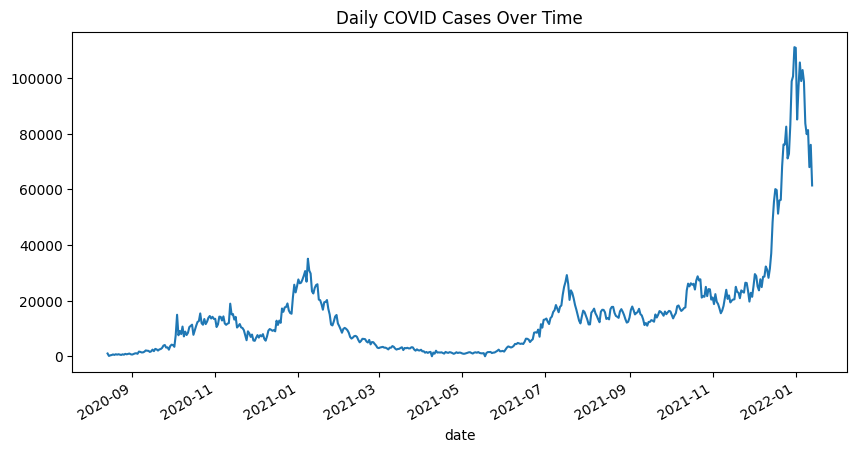

In [316]:
#show daily covid cases trend
df.groupby('date')['newCasesByPublishDate'].sum().plot(figsize=(10,5), title="Daily COVID Cases Over Time")

<Axes: xlabel='day_of_week'>

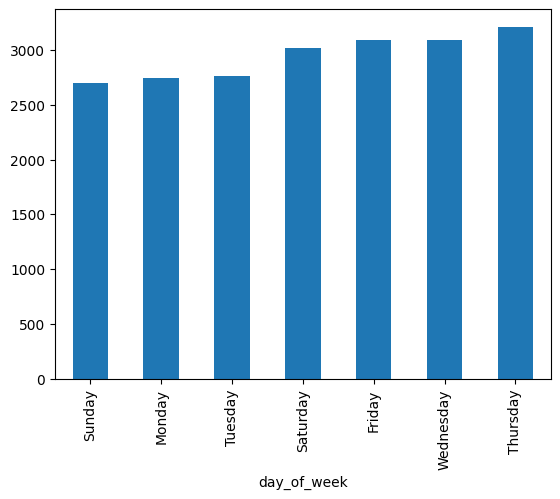

In [317]:
#showing cases by week pattern
df['day_of_week'] = df['date'].dt.day_name()

df.groupby('day_of_week')['newCasesByPublishDate'].mean().sort_values().plot(kind='bar')

<Axes: >

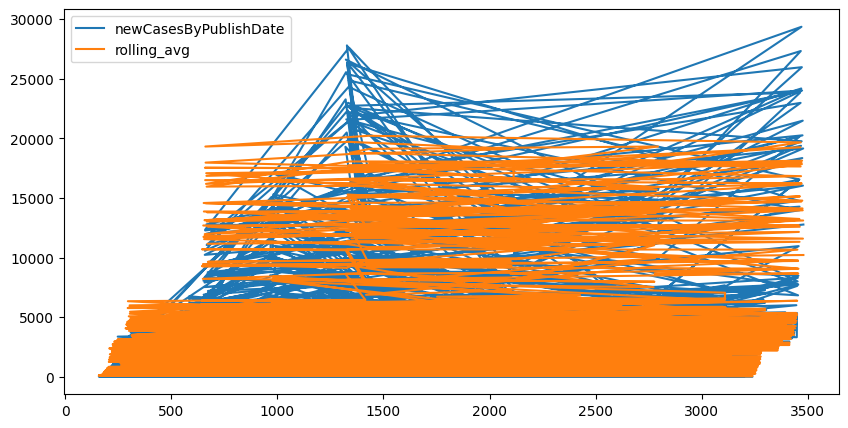

In [318]:
#show trends more clearly
df['rolling_avg'] = df['newCasesByPublishDate'].rolling(window=7).mean()

df[['newCasesByPublishDate', 'rolling_avg']].plot(figsize=(10,5))

<Axes: >

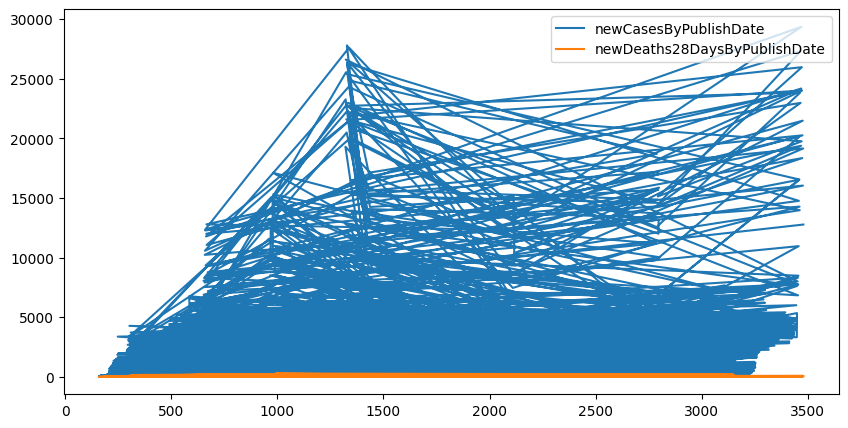

In [319]:
#Compares infection vs mortality trends
df[['newCasesByPublishDate', 'newDeaths28DaysByPublishDate']].plot(figsize=(10,5))


In [320]:
df.groupby('areaName')['cumDeaths28DaysByDeathDateRate'].max().sort_values(ascending=False).head()

areaName
North West                  289.8
East Midlands               247.6
East of England             243.6
Yorkshire and The Humber    242.5
London                      199.6
Name: cumDeaths28DaysByDeathDateRate, dtype: float64

In [321]:
df_region = df[df['areaName'] == 'London']

In [322]:
df_region.set_index('date', inplace=True)
ts = df_region['newCasesByPublishDate']

In [323]:
train = ts[:'2021-12-31']
test = ts['2022-01-01':]

In [324]:
df_region['lag1'] = ts.shift(1)
df_region['lag7'] = ts.shift(7)

df_region = df_region.dropna()

X = df_region[['lag1','lag7']]
y = df_region['newCasesByPublishDate']

In [325]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

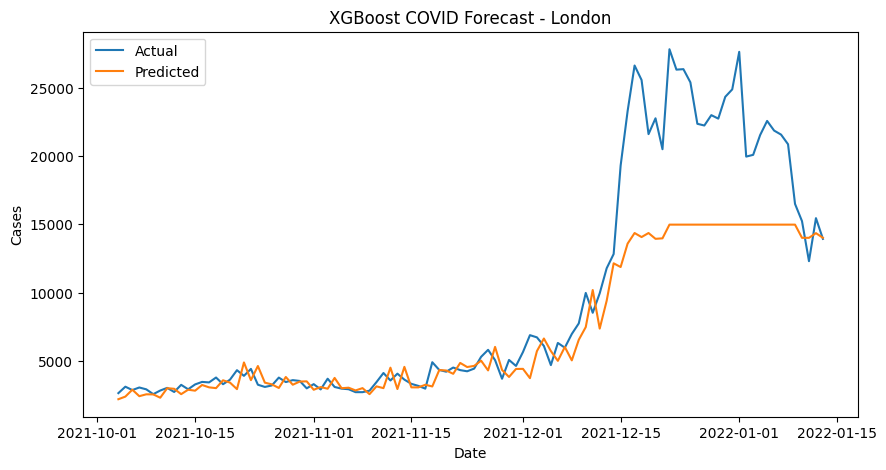

In [326]:
import matplotlib.pyplot as plt
# Prediction
#y_pred = model.predict(X_test)

# ADD THIS LINE (fix)
forecast = y_pred
plt.figure(figsize=(10,5))

plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, forecast, label="Predicted")

plt.title("XGBoost COVID Forecast - London")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend()

plt.show()

In [327]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, forecast)
print("MAE:", mae)

MAE: 2656.157039866728


In [328]:
#XGboost ML model
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [329]:
y_pred = model.predict(X_test)
forecast = y_pred

In [330]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("XGBoost MAE:", mae)
print("XGBoost RMSE:", rmse)

XGBoost MAE: 2656.157039866728
XGBoost RMSE: 4492.783947898016


In [331]:
# Model performance
mae = mean_absolute_error(y_test, y_pred)

# Baseline
baseline_pred = y_test.shift(1).bfill()
baseline_mae = mean_absolute_error(y_test, baseline_pred)

# Compare
print("Model MAE:", mae)
print("Baseline MAE:", baseline_mae)
print("Improvement:", baseline_mae - mae)

Model MAE: 2656.157039866728
Baseline MAE: 1044.2254901960785
Improvement: -1611.9315496706497


In [332]:
print("Improvement over baseline:", baseline_mae - mae)

Improvement over baseline: -1611.9315496706497


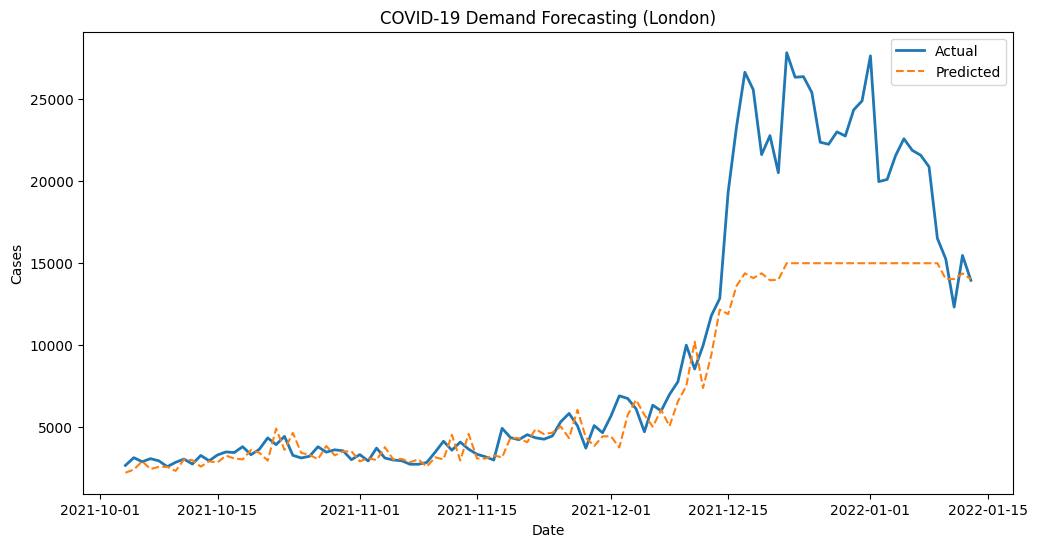

In [333]:
plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test, label="Actual", linewidth=2)
plt.plot(y_test.index, y_pred, label="Predicted", linestyle='--')

plt.title("COVID-19 Demand Forecasting (London)")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend()

plt.show()

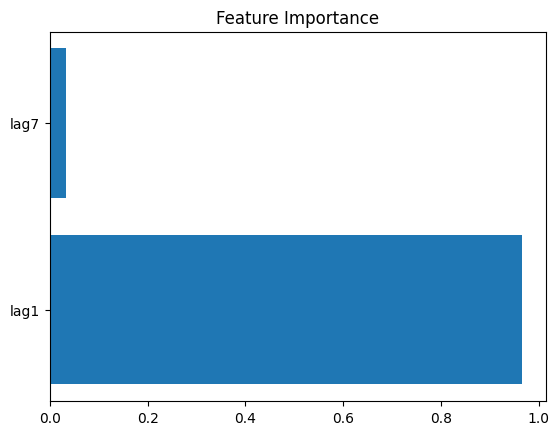

In [334]:
importances = model.feature_importances_
features = X_train.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [335]:
results = pd.DataFrame({
    'date': y_test.index,
    'actual_cases': y_test.values,
    'predicted_cases': y_pred
})

In [336]:
print(results.head())

        date  actual_cases  predicted_cases
0 2021-10-04        2665.0      2219.637939
1 2021-10-05        3135.0      2411.747070
2 2021-10-06        2890.0      2914.261963
3 2021-10-07        3077.0      2442.799561
4 2021-10-08        2942.0      2578.518066


In [338]:
results.to_csv("C:/Users/vvahe/Desktop/forecast_results.csv", index=False)